# IEMOCAP & MELD Temporal Data Analysis

Notebook này phân tích dữ liệu hội thoại ở mức dialogue/session/split để xem các tín hiệu thời gian có hỗ trợ idea TIM không.

Trọng tâm:

- duration của utterance
- gap giữa hai lượt nói liên tiếp
- overlap/interruption
- speaker switch
- vị trí lượt nói trong dialogue
- emotion transition giữa các lượt nói

Phần IEMOCAP dùng session-level analysis. Phần MELD dùng train/dev/test và có thêm Season/Episode từ metadata. Notebook không load model/checkpoint.


In [17]:
from pathlib import Path
import os
import sys
from collections import Counter

CWD = Path.cwd().resolve()
os.environ.setdefault('MPLCONFIGDIR', str(CWD / '.matplotlib_cache'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

if (CWD / 'utils').is_dir() and (CWD / 'iemocap').is_dir():
    PROJECT_ROOT = CWD
elif CWD.name in {'notebook', 'notebooks'} and (CWD.parent / 'utils').is_dir():
    PROJECT_ROOT = CWD.parent
else:
    # Manual fallback: set SER_PROJECT_ROOT before running if your notebook server starts elsewhere.
    PROJECT_ROOT = Path(os.environ.get('SER_PROJECT_ROOT', CWD)).resolve()

assert (PROJECT_ROOT / 'utils').is_dir(), f'Không tìm thấy utils/ từ PROJECT_ROOT={PROJECT_ROOT}'
assert (PROJECT_ROOT / 'iemocap').is_dir(), f'Không tìm thấy iemocap/ từ PROJECT_ROOT={PROJECT_ROOT}'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.iemocap_kaggle import LABEL_NAMES, MELD_RAW_LABEL_MAP, discover_iemocap_samples

IEMOCAP_ROOT = Path(os.environ.get('IEMOCAP_ROOT', PROJECT_ROOT / 'iemocap')).resolve()
REPORT_DIR = PROJECT_ROOT / 'reports' / 'iemocap_temporal_session_analysis'
MELD_REPORT_DIR = PROJECT_ROOT / 'reports' / 'meld_temporal_analysis'
COMPARISON_REPORT_DIR = PROJECT_ROOT / 'reports' / 'temporal_dataset_comparison'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MELD_REPORT_DIR.mkdir(parents=True, exist_ok=True)
COMPARISON_REPORT_DIR.mkdir(parents=True, exist_ok=True)
MELD_ROOT = Path(os.environ.get('MELD_ROOT', PROJECT_ROOT / 'data' / 'meld-dataset' / 'MELD-RAW' / 'MELD.Raw')).resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)
print('IEMOCAP_ROOT =', IEMOCAP_ROOT)
print('REPORT_DIR   =', REPORT_DIR)
print('MELD_ROOT    =', MELD_ROOT)
print('MELD_REPORT  =', MELD_REPORT_DIR)


PROJECT_ROOT = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo
IEMOCAP_ROOT = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/iemocap
REPORT_DIR   = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/iemocap_temporal_session_analysis
MELD_ROOT    = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/data/meld-dataset/MELD-RAW/MELD.Raw
MELD_REPORT  = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_temporal_analysis


## 1. Load IEMOCAP Metadata

Dùng parser hiện có trong repo, nên emotion mapping giống training pipeline hiện tại: 8-class raw label được map về 4 class `angry/happy/neutral/sad`, còn `xxx/oth` bị loại khỏi supervised label.


In [18]:
samples = discover_iemocap_samples(IEMOCAP_ROOT, auto_download=False)
rows = []
for sample in samples:
    rows.append({
        'session': f'Ses{sample.session_id:02d}',
        'session_id': sample.session_id,
        'dialogue_id': sample.dialogue_id,
        'utterance_id': sample.utterance_id,
        'speaker_id': sample.speaker_id,
        'speaker_role': sample.speaker_id.split('_')[-1],
        'start_time': float(sample.start_time),
        'end_time': float(sample.end_time),
        'emotion': sample.label_name,
        'raw_emotion': sample.raw_label,
        'transcript': sample.transcript,
        'audio_path': sample.audio_path,
    })

base_df = pd.DataFrame(rows)
base_df = base_df.sort_values(['session_id', 'dialogue_id', 'start_time', 'end_time', 'utterance_id']).reset_index(drop=True)
base_df['duration'] = (base_df['end_time'] - base_df['start_time']).clip(lower=0)
print('utterances:', len(base_df))
print('dialogues:', base_df['dialogue_id'].nunique())
print('sessions:', sorted(base_df['session'].unique()))
base_df.head()


utterances: 7529
dialogues: 151
sessions: ['Ses01', 'Ses02', 'Ses03', 'Ses04', 'Ses05']


,session,session_id,dialogue_id,utterance_id,speaker_id,speaker_role,start_time,end_time,emotion,raw_emotion,transcript,audio_path,duration
0,Ses01,1,Ses01F_impro01,Ses01F_impro01_F000,Ses01_F,F,6.2901,8.2357,neutral,neu,Excuse me.,/Users/ngocbao/Documents/Document/research/mai...,1.9456
1,Ses01,1,Ses01F_impro01,Ses01F_impro01_M000,Ses01_M,M,7.5712,10.4750,angry,fru,Do you have your forms?,/Users/ngocbao/Documents/Document/research/mai...,2.9038
2,Ses01,1,Ses01F_impro01,Ses01F_impro01_F001,Ses01_F,F,10.0100,11.3925,neutral,neu,Yeah.,/Users/ngocbao/Documents/Document/research/mai...,1.3825
3,Ses01,1,Ses01F_impro01,Ses01F_impro01_M001,Ses01_M,M,10.9266,14.6649,angry,fru,Let me see them.,/Users/ngocbao/Documents/Document/research/mai...,3.7383
4,Ses01,1,Ses01F_impro01,Ses01F_impro01_F002,Ses01_F,F,14.8872,18.0175,neutral,neu,Is there a problem?,/Users/ngocbao/Documents/Document/research/mai...,3.1303


## 2. Build Temporal Features

Các feature này tương ứng với nhóm TIM đang dùng: duration, gap, overlap, speaker switch, turn position. Tất cả được tính trong từng dialogue để tránh trộn session/dialogue.


In [19]:
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    output = []
    for _, dialogue in df.groupby('dialogue_id', sort=False):
        dialogue = dialogue.sort_values(['start_time', 'end_time', 'utterance_id']).reset_index(drop=True).copy()
        n = len(dialogue)
        prev_end = dialogue['end_time'].shift(1)
        prev_start = dialogue['start_time'].shift(1)
        prev_speaker = dialogue['speaker_id'].shift(1)
        prev_emotion = dialogue['emotion'].shift(1)
        next_start = dialogue['start_time'].shift(-1)

        dialogue['turn_index'] = np.arange(n)
        dialogue['turn_position'] = dialogue['turn_index'] / max(n - 1, 1)
        dialogue['dialogue_len'] = n
        dialogue['gap_prev'] = dialogue['start_time'] - prev_end
        dialogue.loc[dialogue['turn_index'] == 0, 'gap_prev'] = np.nan
        dialogue['gap_next'] = next_start - dialogue['end_time']
        dialogue['overlap_prev'] = (prev_end - dialogue['start_time']).clip(lower=0)
        dialogue.loc[dialogue['turn_index'] == 0, 'overlap_prev'] = 0.0
        dialogue['overlap_ratio'] = dialogue['overlap_prev'] / dialogue['duration'].replace(0, np.nan)
        dialogue['overlap_ratio'] = dialogue['overlap_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0)
        dialogue['has_overlap'] = dialogue['overlap_prev'] > 0
        dialogue['speaker_switch'] = dialogue['speaker_id'] != prev_speaker
        dialogue.loc[dialogue['turn_index'] == 0, 'speaker_switch'] = False
        dialogue['same_speaker'] = ~dialogue['speaker_switch']
        dialogue.loc[dialogue['turn_index'] == 0, 'same_speaker'] = False
        dialogue['is_interrupting'] = dialogue['has_overlap'] & dialogue['speaker_switch']
        dialogue['prev_emotion'] = prev_emotion
        dialogue['emotion_transition'] = dialogue['prev_emotion'].fillna('START') + ' -> ' + dialogue['emotion']
        dialogue['emotion_changed'] = (dialogue['prev_emotion'].notna()) & (dialogue['prev_emotion'] != dialogue['emotion'])
        dialogue['short_gap'] = dialogue['gap_prev'].between(0, 0.3, inclusive='both')
        dialogue['long_gap'] = dialogue['gap_prev'] > 1.0
        dialogue['early_turn'] = dialogue['turn_position'] <= 0.33
        dialogue['middle_turn'] = dialogue['turn_position'].between(0.33, 0.66, inclusive='right')
        dialogue['late_turn'] = dialogue['turn_position'] > 0.66
        output.append(dialogue)
    return pd.concat(output, ignore_index=True)

df = add_temporal_features(base_df)
df.to_csv(REPORT_DIR / 'iemocap_temporal_features_by_utterance.csv', index=False)
df.head()


,session,session_id,dialogue_id,utterance_id,speaker_id,speaker_role,start_time,end_time,emotion,raw_emotion,...,same_speaker,is_interrupting,prev_emotion,emotion_transition,emotion_changed,short_gap,long_gap,early_turn,middle_turn,late_turn
0,Ses01,1,Ses01F_impro01,Ses01F_impro01_F000,Ses01_F,F,6.2901,8.2357,neutral,neu,...,False,False,NaN,START -> neutral,False,False,False,True,False,False
1,Ses01,1,Ses01F_impro01,Ses01F_impro01_M000,Ses01_M,M,7.5712,10.4750,angry,fru,...,False,True,neutral,neutral -> angry,True,False,False,True,False,False
2,Ses01,1,Ses01F_impro01,Ses01F_impro01_F001,Ses01_F,F,10.0100,11.3925,neutral,neu,...,False,True,angry,angry -> neutral,True,False,False,True,False,False
3,Ses01,1,Ses01F_impro01,Ses01F_impro01_M001,Ses01_M,M,10.9266,14.6649,angry,fru,...,False,True,neutral,neutral -> angry,True,False,False,True,False,False
4,Ses01,1,Ses01F_impro01,Ses01F_impro01_F002,Ses01_F,F,14.8872,18.0175,neutral,neu,...,False,False,angry,angry -> neutral,True,True,False,True,False,False


## 3. Session-Level Temporal Summary

Bảng này trả lời câu hỏi: các session có khác nhau rõ về nhịp hội thoại không? Nếu có, TIM có cơ hội học thêm thông tin ngoài acoustic embedding.


In [20]:
def pct(series):
    return float(series.mean()) if len(series) else 0.0

session_summary = (
    df.groupby('session')
    .agg(
        utterances=('utterance_id', 'count'),
        dialogues=('dialogue_id', 'nunique'),
        mean_dialogue_len=('dialogue_len', 'mean'),
        duration_mean=('duration', 'mean'),
        duration_median=('duration', 'median'),
        gap_prev_mean=('gap_prev', 'mean'),
        gap_prev_median=('gap_prev', 'median'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
        short_gap_rate=('short_gap', pct),
        long_gap_rate=('long_gap', pct),
        emotion_change_rate=('emotion_changed', pct),
    )
    .reset_index()
)

for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'short_gap_rate', 'long_gap_rate', 'emotion_change_rate']:
    session_summary[col] = session_summary[col] * 100

session_summary.round(3).to_csv(REPORT_DIR / 'session_temporal_summary.csv', index=False)
session_summary.round(3)


,session,utterances,dialogues,mean_dialogue_len,duration_mean,duration_median,gap_prev_mean,gap_prev_median,overlap_rate,interruption_rate,speaker_switch_rate,short_gap_rate,long_gap_rate,emotion_change_rate
0,Ses01,1403,28,54.887,4.618,3.560,0.806,-0.294,54.669,54.669,69.565,11.262,24.590,37.919
1,Ses02,1374,30,49.201,4.663,3.670,0.703,-0.044,50.291,50.291,67.394,20.160,19.214,31.951
2,Ses03,1564,32,55.656,4.501,3.754,0.812,-0.130,50.384,50.384,64.066,18.606,23.018,33.440
3,Ses04,1538,30,58.560,4.495,3.643,0.638,-0.330,57.802,57.802,68.270,13.914,20.156,27.503
4,Ses05,1650,31,58.628,4.531,3.385,0.656,-0.330,59.394,59.394,72.121,9.515,22.364,32.909


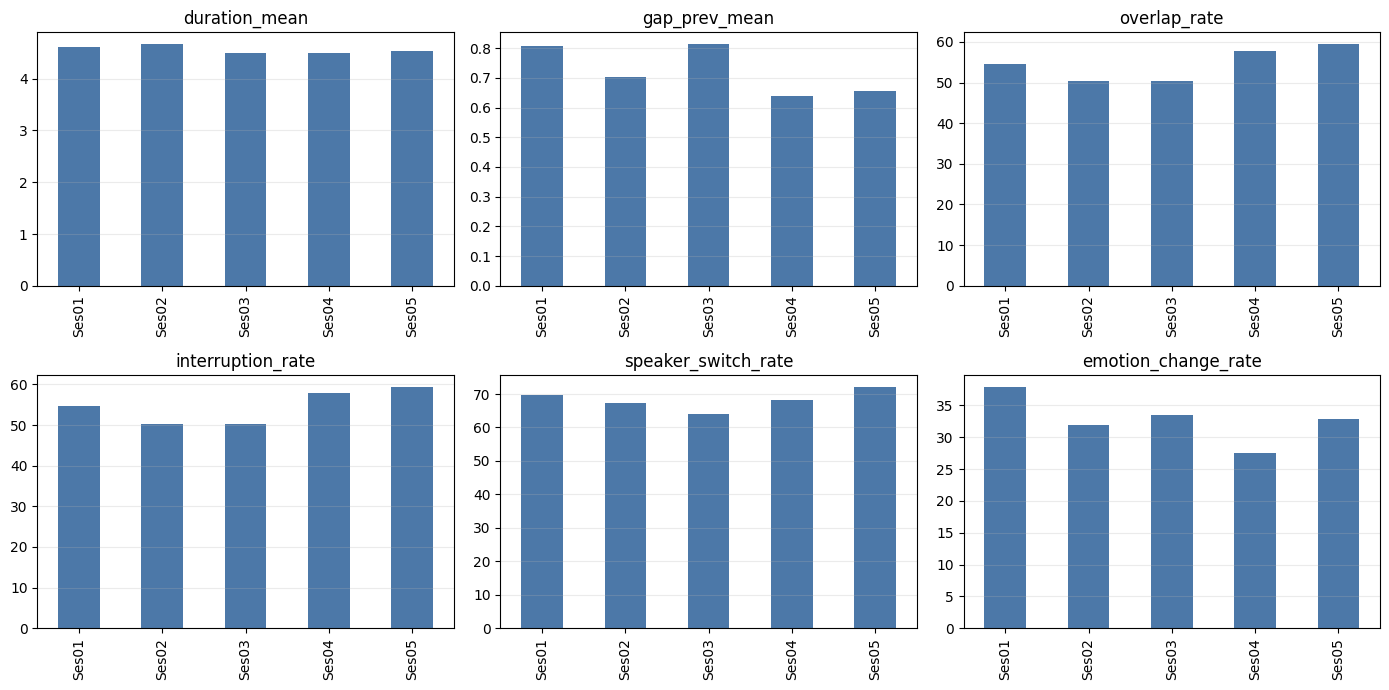

In [21]:
plot_cols = ['duration_mean', 'gap_prev_mean', 'overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'emotion_change_rate']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    session_summary.plot(x='session', y=col, kind='bar', legend=False, ax=ax, color='#4C78A8')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'session_temporal_summary.png', dpi=160)
plt.show()


## 4. Emotion Distribution Per Session

Nếu một session vừa có temporal pattern khác, vừa có emotion distribution khác, TIM có thể tận dụng hoặc bị bias bởi pattern đó. Đây là chỗ cần nhìn khi Session 5 outlier.


In [22]:
emotion_session = pd.crosstab(df['session'], df['emotion'])
emotion_session_ratio = pd.crosstab(df['session'], df['emotion'], normalize='index') * 100
emotion_session.to_csv(REPORT_DIR / 'session_emotion_counts.csv')
emotion_session_ratio.round(2).to_csv(REPORT_DIR / 'session_emotion_ratio.csv')
print('Counts')
display(emotion_session)
print('Ratio (%)')
display(emotion_session_ratio.round(2))


Counts


emotion,angry,happy,neutral,sad
session,,,,
Ses01,510,303,384,206
Ses02,462,344,362,206
Ses03,623,314,320,307
Ses04,808,322,258,150
Ses05,551,460,384,255


Ratio (%)


emotion,angry,happy,neutral,sad
session,,,,
Ses01,36.35,21.60,27.37,14.68
Ses02,33.62,25.04,26.35,14.99
Ses03,39.83,20.08,20.46,19.63
Ses04,52.54,20.94,16.78,9.75
Ses05,33.39,27.88,23.27,15.45


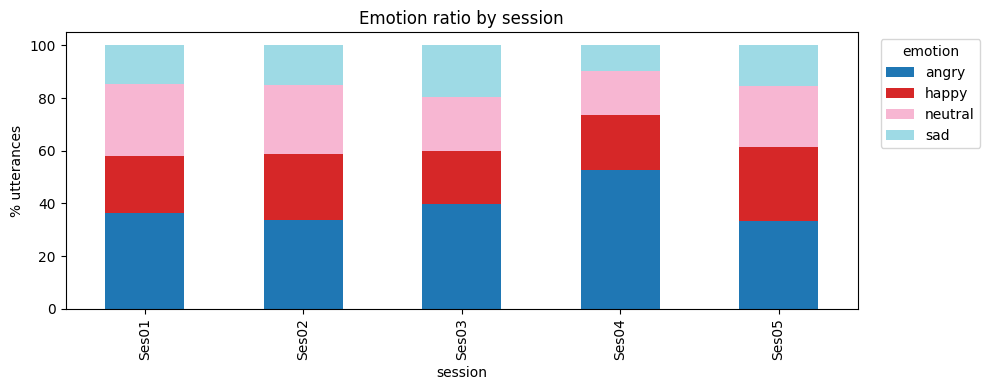

In [23]:
ax = emotion_session_ratio[LABEL_NAMES].plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab20')
ax.set_title('Emotion ratio by session')
ax.set_ylabel('% utterances')
ax.set_xlabel('session')
ax.legend(title='emotion', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'session_emotion_ratio.png', dpi=160)
plt.show()


## 5. Temporal Features By Emotion

Nếu temporal features khác nhau theo emotion, đây là bằng chứng ủng hộ TIM. Ví dụ angry có interruption/overlap cao hơn, sad có duration/gap dài hơn, neutral nằm nhiều ở vùng ít overlap.


In [24]:
emotion_temporal = (
    df.groupby('emotion')
    .agg(
        n=('utterance_id', 'count'),
        duration_mean=('duration', 'mean'),
        duration_median=('duration', 'median'),
        gap_prev_mean=('gap_prev', 'mean'),
        gap_prev_median=('gap_prev', 'median'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
        short_gap_rate=('short_gap', pct),
        long_gap_rate=('long_gap', pct),
        mean_turn_position=('turn_position', 'mean'),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'short_gap_rate', 'long_gap_rate']:
    emotion_temporal[col] = emotion_temporal[col] * 100
emotion_temporal.round(3).to_csv(REPORT_DIR / 'emotion_temporal_summary.csv', index=False)
emotion_temporal.round(3)


,emotion,n,duration_mean,duration_median,gap_prev_mean,gap_prev_median,overlap_rate,interruption_rate,speaker_switch_rate,short_gap_rate,long_gap_rate,mean_turn_position
0,angry,2954,4.635,3.750,0.315,-0.430,63.744,63.744,74.272,12.864,18.009,0.517
1,happy,1743,4.528,3.640,0.964,-0.097,50.373,50.373,62.478,17.613,23.752,0.504
2,neutral,1708,3.902,3.130,0.697,-0.289,56.148,56.148,69.087,12.354,21.604,0.447
3,sad,1124,5.398,4.052,1.465,0.202,35.142,35.142,60.587,17.705,29.626,0.530


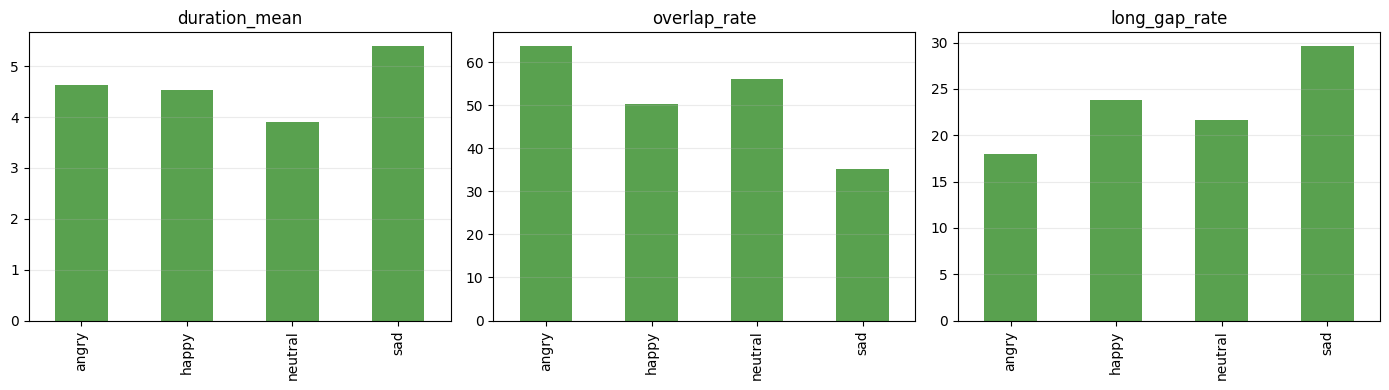

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['duration_mean', 'overlap_rate', 'long_gap_rate']):
    emotion_temporal.plot(x='emotion', y=col, kind='bar', legend=False, ax=ax, color='#59A14F')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'emotion_temporal_summary.png', dpi=160)
plt.show()


## 6. Session x Emotion Temporal Summary

Bảng này quan trọng để xem TIM có đang học tín hiệu ổn định hay chỉ học bias của một session. Nếu overlap chỉ mạnh ở một session/emotion cụ thể, nó có thể gây nhiễu khi LOSO.


In [26]:
session_emotion_temporal = (
    df.groupby(['session', 'emotion'])
    .agg(
        n=('utterance_id', 'count'),
        duration_mean=('duration', 'mean'),
        gap_prev_mean=('gap_prev', 'mean'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
        long_gap_rate=('long_gap', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'long_gap_rate']:
    session_emotion_temporal[col] = session_emotion_temporal[col] * 100
session_emotion_temporal.round(3).to_csv(REPORT_DIR / 'session_emotion_temporal_summary.csv', index=False)
session_emotion_temporal.round(3)


,session,emotion,n,duration_mean,gap_prev_mean,overlap_rate,interruption_rate,speaker_switch_rate,long_gap_rate
0,Ses01,angry,510,4.708,0.214,63.922,63.922,75.490,18.824
1,Ses01,happy,303,4.925,1.004,55.446,55.446,67.987,24.752
2,Ses01,neutral,384,3.731,0.915,53.385,53.385,66.667,23.958
3,Ses01,sad,206,5.601,1.795,33.010,33.010,62.621,39.806
4,Ses02,angry,462,4.606,0.373,63.853,63.853,77.273,13.853
5,Ses02,happy,344,4.321,1.016,43.895,43.895,56.977,23.837
6,Ses02,neutral,362,4.466,0.399,49.724,49.724,66.851,18.232
7,Ses02,sad,206,5.712,1.468,31.553,31.553,63.592,25.243
8,Ses03,angry,623,4.667,0.241,60.353,60.353,70.626,19.583
9,Ses03,happy,314,4.731,1.412,38.535,38.535,55.096,29.936


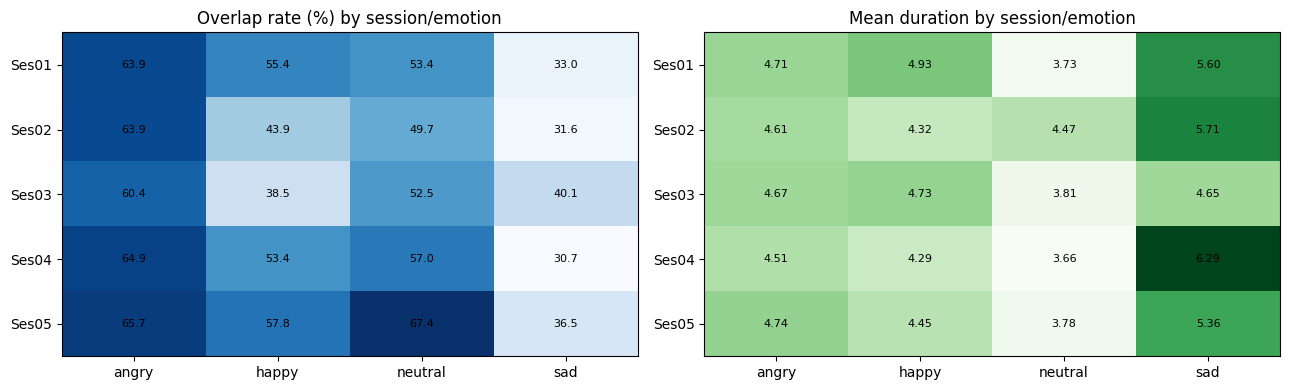

In [27]:
pivot_overlap = session_emotion_temporal.pivot(index='session', columns='emotion', values='overlap_rate').reindex(columns=LABEL_NAMES)
pivot_duration = session_emotion_temporal.pivot(index='session', columns='emotion', values='duration_mean').reindex(columns=LABEL_NAMES)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(pivot_overlap.fillna(0).to_numpy(), aspect='auto', cmap='Blues')
axes[0].set_title('Overlap rate (%) by session/emotion')
axes[0].set_xticks(range(len(pivot_overlap.columns)), pivot_overlap.columns)
axes[0].set_yticks(range(len(pivot_overlap.index)), pivot_overlap.index)
for i in range(pivot_overlap.shape[0]):
    for j in range(pivot_overlap.shape[1]):
        axes[0].text(j, i, f'{pivot_overlap.iloc[i, j]:.1f}', ha='center', va='center', fontsize=8)

axes[1].imshow(pivot_duration.fillna(0).to_numpy(), aspect='auto', cmap='Greens')
axes[1].set_title('Mean duration by session/emotion')
axes[1].set_xticks(range(len(pivot_duration.columns)), pivot_duration.columns)
axes[1].set_yticks(range(len(pivot_duration.index)), pivot_duration.index)
for i in range(pivot_duration.shape[0]):
    for j in range(pivot_duration.shape[1]):
        axes[1].text(j, i, f'{pivot_duration.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'session_emotion_temporal_heatmaps.png', dpi=160)
plt.show()


## 7. Emotion Transitions

TIM có thể hữu ích nếu emotion phụ thuộc vào nhịp chuyển lượt và trạng thái trước đó, ví dụ `neutral -> angry`, `angry -> angry`, hoặc các đoạn có interruption.


In [28]:
transition_counts = (
    df[df['prev_emotion'].notna()]
    .groupby(['prev_emotion', 'emotion'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
)
transition_counts.to_csv(REPORT_DIR / 'emotion_transition_counts.csv', index=False)
transition_counts.head(20)


,prev_emotion,emotion,count
0,angry,angry,2118
5,happy,happy,1326
15,sad,sad,786
10,neutral,neutral,688
8,neutral,angry,625
2,angry,neutral,600
9,neutral,happy,237
6,happy,neutral,232
11,neutral,sad,131
14,sad,neutral,129


In [29]:
transition_temporal = (
    df[df['prev_emotion'].notna()]
    .groupby(['prev_emotion', 'emotion'])
    .agg(
        n=('utterance_id', 'count'),
        duration_mean=('duration', 'mean'),
        gap_prev_mean=('gap_prev', 'mean'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate']:
    transition_temporal[col] = transition_temporal[col] * 100
transition_temporal = transition_temporal.sort_values(['n', 'overlap_rate'], ascending=[False, False])
transition_temporal.round(3).to_csv(REPORT_DIR / 'emotion_transition_temporal_summary.csv', index=False)
transition_temporal.head(20).round(3)


,prev_emotion,emotion,n,duration_mean,gap_prev_mean,overlap_rate,interruption_rate,speaker_switch_rate
0,angry,angry,2118,4.603,0.253,61.426,61.426,71.105
5,happy,happy,1326,4.457,0.707,48.567,48.567,59.351
15,sad,sad,786,5.620,1.159,30.407,30.407,54.707
10,neutral,neutral,688,4.026,1.080,39.680,39.680,48.837
8,neutral,angry,625,4.750,0.077,76.480,76.480,87.360
2,angry,neutral,600,4.096,-0.045,74.833,74.833,88.167
9,neutral,happy,237,4.556,1.140,65.823,65.823,80.169
6,happy,neutral,232,3.140,0.967,71.983,71.983,86.207
11,neutral,sad,131,4.654,0.899,58.779,58.779,91.603
14,sad,neutral,129,3.988,1.618,54.264,54.264,89.147


## 8. Quick Evidence For/Against TIM

Cell này tự tạo một bảng kết luận ngắn. Đây không phải kết quả model, nhưng giúp quyết định temporal cue nào đáng giữ hoặc cần ablation.


In [30]:
evidence_rows = []

# Feature variability across emotions: large range means feature can carry emotion information.
for feature in ['duration_mean', 'gap_prev_mean', 'overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'long_gap_rate']:
    values = emotion_temporal.set_index('emotion')[feature].dropna()
    evidence_rows.append({
        'question': 'emotion_separability',
        'feature': feature,
        'range_across_emotions': float(values.max() - values.min()),
        'max_emotion': values.idxmax(),
        'min_emotion': values.idxmin(),
    })

# Session instability: large range means cue may be useful but also risky under LOSO.
for feature in ['duration_mean', 'gap_prev_mean', 'overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'emotion_change_rate']:
    values = session_summary.set_index('session')[feature].dropna()
    evidence_rows.append({
        'question': 'session_instability',
        'feature': feature,
        'range_across_sessions': float(values.max() - values.min()),
        'max_session': values.idxmax(),
        'min_session': values.idxmin(),
    })

evidence_df = pd.DataFrame(evidence_rows)
evidence_df.to_csv(REPORT_DIR / 'tim_temporal_evidence_summary.csv', index=False)
evidence_df


,question,feature,range_across_emotions,max_emotion,min_emotion,range_across_sessions,max_session,min_session
0,emotion_separability,duration_mean,1.495884,sad,neutral,NaN,NaN,NaN
1,emotion_separability,gap_prev_mean,1.150207,sad,angry,NaN,NaN,NaN
2,emotion_separability,overlap_rate,28.601727,angry,sad,NaN,NaN,NaN
3,emotion_separability,interruption_rate,28.601727,angry,sad,NaN,NaN,NaN
4,emotion_separability,speaker_switch_rate,13.684985,angry,sad,NaN,NaN,NaN
5,emotion_separability,long_gap_rate,11.616856,sad,angry,NaN,NaN,NaN
6,session_instability,duration_mean,NaN,NaN,NaN,0.168747,Ses02,Ses04
7,session_instability,gap_prev_mean,NaN,NaN,NaN,0.174915,Ses03,Ses04
8,session_instability,overlap_rate,NaN,NaN,NaN,9.102819,Ses05,Ses02
9,session_instability,interruption_rate,NaN,NaN,NaN,9.102819,Ses05,Ses02


In [31]:
print('Saved reports to:', REPORT_DIR)
for path in sorted(REPORT_DIR.glob('*')):
    print('-', path.name)


Saved reports to: /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/iemocap_temporal_session_analysis
- emotion_temporal_summary.csv
- emotion_temporal_summary.png
- emotion_transition_counts.csv
- emotion_transition_temporal_summary.csv
- iemocap_temporal_features_by_utterance.csv
- session_emotion_counts.csv
- session_emotion_ratio.csv
- session_emotion_ratio.png
- session_emotion_temporal_heatmaps.png
- session_emotion_temporal_summary.csv
- session_temporal_summary.csv
- session_temporal_summary.png
- tim_temporal_evidence_summary.csv


## 9. Load MELD Metadata

MELD có `StartTime` và `EndTime` trong các file `*_sent_emo.csv`. Khác IEMOCAP, MELD là multi-party và có `Season`, `Episode`, `Dialogue_ID`, `Utterance_ID`. Ở đây ta map emotion 7-class của MELD về 4-class giống pipeline hiện tại để phân tích TIM nhất quán.


In [32]:
MELD_CSV_PATHS = {
    'train': MELD_ROOT / 'train' / 'train_sent_emo.csv',
    'dev': MELD_ROOT / 'dev_sent_emo.csv',
    'test': MELD_ROOT / 'test_sent_emo.csv',
}

def parse_meld_time(value) -> float:
    text = str(value).strip().replace(',', '.')
    parts = text.split(':')
    if len(parts) != 3:
        return np.nan
    hours, minutes, seconds = parts
    return int(hours) * 3600.0 + int(minutes) * 60.0 + float(seconds)

meld_rows = []
for split, csv_path in MELD_CSV_PATHS.items():
    assert csv_path.is_file(), f'Missing MELD CSV: {csv_path}'
    split_df = pd.read_csv(csv_path)
    for _, row in split_df.iterrows():
        raw_emotion = str(row['Emotion']).lower()
        mapped_emotion = MELD_RAW_LABEL_MAP.get(raw_emotion)
        if mapped_emotion is None:
            continue
        dialogue_id = f"MELD_{split}_dia{int(row['Dialogue_ID'])}"
        utterance_id = f"{dialogue_id}_utt{int(row['Utterance_ID'])}"
        meld_rows.append({
            'dataset': 'MELD',
            'split': split,
            'session': split,
            'season': int(row['Season']),
            'episode': int(row['Episode']),
            'dialogue_id': dialogue_id,
            'utterance_id': utterance_id,
            'dialogue_index': int(row['Dialogue_ID']),
            'utterance_index': int(row['Utterance_ID']),
            'speaker_id': str(row['Speaker']),
            'start_time': parse_meld_time(row['StartTime']),
            'end_time': parse_meld_time(row['EndTime']),
            'emotion': mapped_emotion,
            'raw_emotion': raw_emotion,
            'sentiment': row['Sentiment'],
            'transcript': row['Utterance'],
        })

meld_base_df = pd.DataFrame(meld_rows)
meld_base_df = meld_base_df.dropna(subset=['start_time', 'end_time']).copy()
meld_base_df = meld_base_df.sort_values(['split', 'dialogue_index', 'utterance_index']).reset_index(drop=True)
meld_base_df['duration'] = (meld_base_df['end_time'] - meld_base_df['start_time']).clip(lower=0)
meld_base_df.to_csv(MELD_REPORT_DIR / 'meld_metadata_4class.csv', index=False)

print('MELD utterances:', len(meld_base_df))
print('MELD dialogues:', meld_base_df['dialogue_id'].nunique())
print('splits:', meld_base_df['split'].value_counts().to_dict())
print('raw emotions:', meld_base_df['raw_emotion'].value_counts().to_dict())
meld_base_df.head()


MELD utterances: 13708
MELD dialogues: 1432
splits: {'train': 9989, 'test': 2610, 'dev': 1109}
raw emotions: {'neutral': 6436, 'joy': 2308, 'surprise': 1636, 'anger': 1607, 'sadness': 1002, 'disgust': 361, 'fear': 358}


,dataset,split,session,season,episode,dialogue_id,utterance_id,dialogue_index,utterance_index,speaker_id,start_time,end_time,emotion,raw_emotion,sentiment,transcript,duration
0,MELD,dev,dev,4,7,MELD_dev_dia0,MELD_dev_dia0_utt0,0,0,Phoebe,1257.256,1260.049,sad,sadness,negative,"Oh my God, hes lost it. Hes totally lost it.",2.793
1,MELD,dev,dev,4,7,MELD_dev_dia0,MELD_dev_dia0_utt1,0,1,Monica,1261.927,1263.261,happy,surprise,negative,What?,1.334
2,MELD,dev,dev,4,4,MELD_dev_dia1,MELD_dev_dia1_utt0,1,0,Ross,744.660,750.915,neutral,neutral,neutral,"Or! Or, we could go to the bank, close our acc...",6.255
3,MELD,dev,dev,4,4,MELD_dev_dia1,MELD_dev_dia1_utt1,1,1,Chandler,752.334,753.960,happy,joy,positive,Youre a genius!,1.626
4,MELD,dev,dev,4,4,MELD_dev_dia1,MELD_dev_dia1_utt2,1,2,Joey,754.211,757.505,sad,sadness,negative,"Aww, man, now we wont be bank buddies!",3.294


## 10. MELD Temporal Features

Dùng cùng hàm `add_temporal_features()` với IEMOCAP. Với MELD, overlap được kỳ vọng thấp hơn vì timestamp đến từ subtitle/clip segmentation, nên gap/duration/speaker dynamics có thể quan trọng hơn overlap.


In [33]:
meld_df = add_temporal_features(meld_base_df)
meld_df.to_csv(MELD_REPORT_DIR / 'meld_temporal_features_by_utterance.csv', index=False)

meld_split_summary = (
    meld_df.groupby('split')
    .agg(
        utterances=('utterance_id', 'count'),
        dialogues=('dialogue_id', 'nunique'),
        seasons=('season', 'nunique'),
        episodes=('episode', 'nunique'),
        speakers=('speaker_id', 'nunique'),
        mean_dialogue_len=('dialogue_len', 'mean'),
        duration_mean=('duration', 'mean'),
        duration_median=('duration', 'median'),
        gap_prev_mean=('gap_prev', 'mean'),
        gap_prev_median=('gap_prev', 'median'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
        short_gap_rate=('short_gap', pct),
        long_gap_rate=('long_gap', pct),
        emotion_change_rate=('emotion_changed', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'short_gap_rate', 'long_gap_rate', 'emotion_change_rate']:
    meld_split_summary[col] = meld_split_summary[col] * 100
meld_split_summary.round(3).to_csv(MELD_REPORT_DIR / 'meld_split_temporal_summary.csv', index=False)
meld_split_summary.round(3)


,split,utterances,dialogues,seasons,episodes,speakers,mean_dialogue_len,duration_mean,duration_median,gap_prev_mean,gap_prev_median,overlap_rate,interruption_rate,speaker_switch_rate,short_gap_rate,long_gap_rate,emotion_change_rate
0,dev,1109,114,9,25,47,12.764,3.117,2.454,1.394,0.209,6.132,4.148,70.604,46.528,25.699,49.775
1,test,2610,280,9,25,100,12.808,3.309,2.460,2.828,0.188,4.176,2.797,67.625,49.579,25.479,47.816
2,train,9989,1038,9,25,260,13.171,3.139,2.460,1.510,0.209,6.667,4.805,69.516,46.771,26.449,49.605


In [34]:
meld_emotion_summary = (
    meld_df.groupby('emotion')
    .agg(
        n=('utterance_id', 'count'),
        duration_mean=('duration', 'mean'),
        duration_median=('duration', 'median'),
        gap_prev_mean=('gap_prev', 'mean'),
        gap_prev_median=('gap_prev', 'median'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
        short_gap_rate=('short_gap', pct),
        long_gap_rate=('long_gap', pct),
        mean_turn_position=('turn_position', 'mean'),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'short_gap_rate', 'long_gap_rate']:
    meld_emotion_summary[col] = meld_emotion_summary[col] * 100
meld_emotion_summary.round(3).to_csv(MELD_REPORT_DIR / 'meld_emotion_temporal_summary.csv', index=False)
meld_emotion_summary.round(3)


,emotion,n,duration_mean,duration_median,gap_prev_mean,gap_prev_median,overlap_rate,interruption_rate,speaker_switch_rate,short_gap_rate,long_gap_rate,mean_turn_position
0,angry,1968,3.532,2.794,1.144,0.168,6.250,3.455,64.024,54.522,22.409,0.528
1,happy,3944,3.088,2.334,1.772,0.209,6.694,5.502,73.808,44.625,28.119,0.493
2,neutral,6436,3.005,2.376,1.988,0.209,5.671,4.102,69.313,47.110,25.715,0.487
3,sad,1360,3.657,2.878,1.474,0.209,6.691,3.676,63.235,45.368,28.456,0.507


In [35]:
meld_season_summary = (
    meld_df.groupby('season')
    .agg(
        utterances=('utterance_id', 'count'),
        dialogues=('dialogue_id', 'nunique'),
        episodes=('episode', 'nunique'),
        speakers=('speaker_id', 'nunique'),
        duration_mean=('duration', 'mean'),
        gap_prev_mean=('gap_prev', 'mean'),
        overlap_rate=('has_overlap', pct),
        speaker_switch_rate=('speaker_switch', pct),
        emotion_change_rate=('emotion_changed', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'speaker_switch_rate', 'emotion_change_rate']:
    meld_season_summary[col] = meld_season_summary[col] * 100
meld_season_summary.round(3).to_csv(MELD_REPORT_DIR / 'meld_season_temporal_summary.csv', index=False)
meld_season_summary.round(3)


,season,utterances,dialogues,episodes,speakers,duration_mean,gap_prev_mean,overlap_rate,speaker_switch_rate,emotion_change_rate
0,1,1830,200,23,66,3.089,2.384,5.464,69.235,47.869
1,2,417,57,15,22,3.652,2.051,5.755,66.667,40.288
2,3,2270,232,25,70,3.327,1.459,6.608,70.000,49.736
3,4,1543,160,21,54,3.207,1.092,5.574,69.410,49.255
4,5,1741,166,24,54,2.883,1.841,4.825,67.949,49.627
5,6,1981,211,24,54,3.062,2.147,6.613,67.845,49.722
6,7,1711,185,24,52,3.214,1.343,6.604,71.303,50.555
7,8,1588,160,23,48,3.271,1.406,7.116,69.962,50.819
8,9,627,61,11,31,3.175,2.874,6.699,68.421,48.006


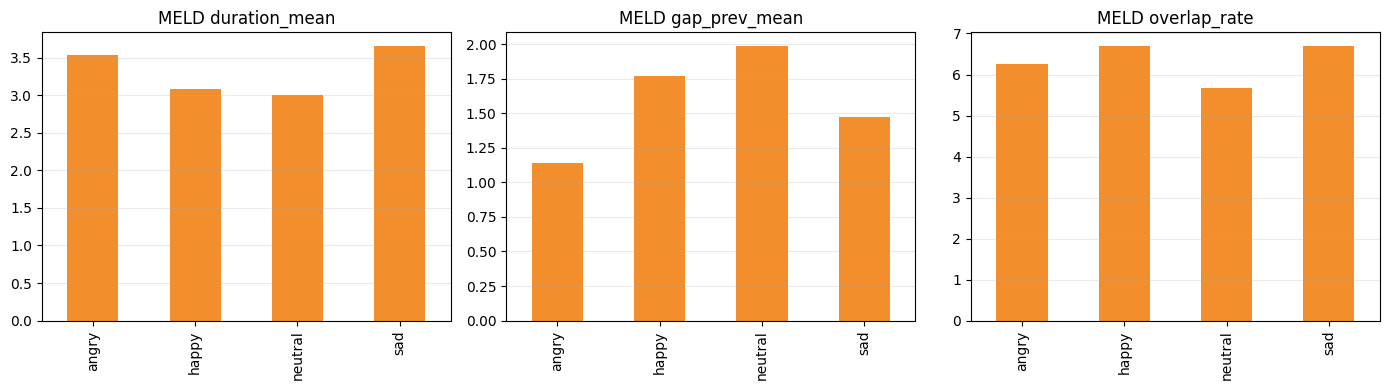

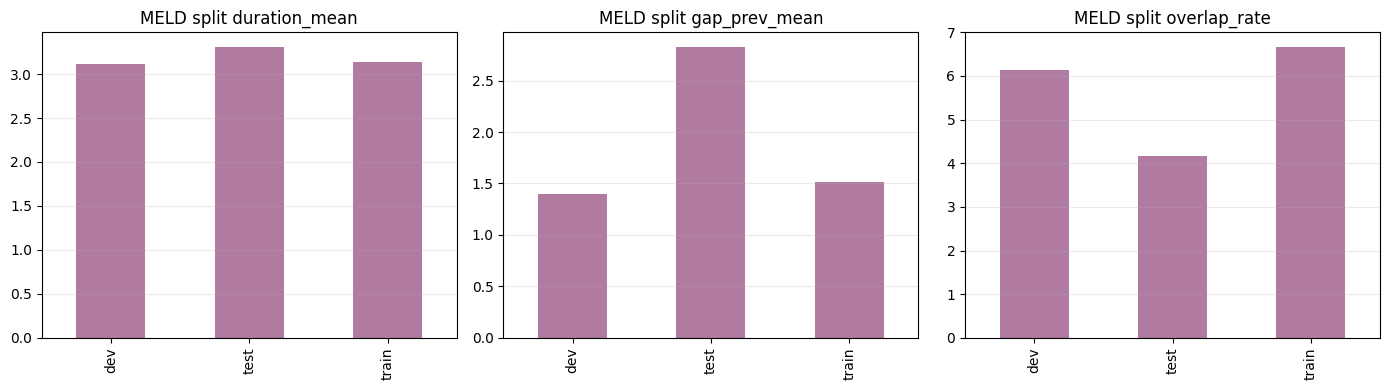

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['duration_mean', 'gap_prev_mean', 'overlap_rate']):
    meld_emotion_summary.plot(x='emotion', y=col, kind='bar', legend=False, ax=ax, color='#F28E2B')
    ax.set_title(f'MELD {col}')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(MELD_REPORT_DIR / 'meld_emotion_temporal_summary.png', dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['duration_mean', 'gap_prev_mean', 'overlap_rate']):
    meld_split_summary.plot(x='split', y=col, kind='bar', legend=False, ax=ax, color='#B07AA1')
    ax.set_title(f'MELD split {col}')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(MELD_REPORT_DIR / 'meld_split_temporal_summary.png', dpi=160)
plt.show()


## 11. MELD Emotion Transitions

MELD là multi-party nên transition còn chịu tác động của speaker re-entry và speaker dominance. Bảng dưới giúp xem các transition nào đi kèm gap/overlap/speaker switch mạnh.


In [37]:
meld_transition_temporal = (
    meld_df[meld_df['prev_emotion'].notna()]
    .groupby(['prev_emotion', 'emotion'])
    .agg(
        n=('utterance_id', 'count'),
        duration_mean=('duration', 'mean'),
        gap_prev_mean=('gap_prev', 'mean'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate']:
    meld_transition_temporal[col] = meld_transition_temporal[col] * 100
meld_transition_temporal = meld_transition_temporal.sort_values(['n', 'overlap_rate'], ascending=[False, False])
meld_transition_temporal.round(3).to_csv(MELD_REPORT_DIR / 'meld_emotion_transition_temporal_summary.csv', index=False)
meld_transition_temporal.head(20).round(3)


,prev_emotion,emotion,n,duration_mean,gap_prev_mean,overlap_rate,interruption_rate,speaker_switch_rate
10,neutral,neutral,3211,3.016,2.016,6.633,4.671,73.217
9,neutral,happy,1514,3.055,2.683,7.596,6.539,87.583
6,happy,neutral,1459,2.987,2.443,5.415,4.249,86.498
5,happy,happy,1371,3.141,0.861,8.023,6.127,76.878
0,angry,angry,622,2.981,0.544,8.039,3.698,50.965
2,angry,neutral,616,2.911,1.580,6.006,4.383,81.656
8,neutral,angry,611,3.643,2.081,5.074,2.946,81.669
11,neutral,sad,453,3.509,0.947,7.947,5.519,77.925
14,sad,neutral,443,2.974,0.848,8.126,5.643,77.878
4,happy,angry,406,3.626,0.985,5.665,3.448,79.803


## 12. IEMOCAP vs MELD Temporal Comparison

So sánh này giúp quyết định feature nào có khả năng generalize. Nếu một feature rất mạnh ở IEMOCAP nhưng yếu ở MELD, nó nên được kiểm soát bằng ablation/gating thay vì hard-code trọng số cao.


In [38]:
iemocap_compare = df.assign(dataset='IEMOCAP', split_or_session=df['session'])
meld_compare = meld_df.assign(dataset='MELD', split_or_session=meld_df['split'])
combined = pd.concat([iemocap_compare, meld_compare], ignore_index=True, sort=False)

comparison = (
    combined.groupby('dataset')
    .agg(
        utterances=('utterance_id', 'count'),
        dialogues=('dialogue_id', 'nunique'),
        duration_mean=('duration', 'mean'),
        duration_median=('duration', 'median'),
        gap_prev_mean=('gap_prev', 'mean'),
        gap_prev_median=('gap_prev', 'median'),
        overlap_rate=('has_overlap', pct),
        interruption_rate=('is_interrupting', pct),
        speaker_switch_rate=('speaker_switch', pct),
        short_gap_rate=('short_gap', pct),
        long_gap_rate=('long_gap', pct),
        emotion_change_rate=('emotion_changed', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'short_gap_rate', 'long_gap_rate', 'emotion_change_rate']:
    comparison[col] = comparison[col] * 100
comparison.round(3).to_csv(COMPARISON_REPORT_DIR / 'iemocap_vs_meld_temporal_summary.csv', index=False)
comparison.round(3)


,dataset,utterances,dialogues,duration_mean,duration_median,gap_prev_mean,gap_prev_median,overlap_rate,interruption_rate,speaker_switch_rate,short_gap_rate,long_gap_rate,emotion_change_rate
0,IEMOCAP,7529,151,4.558,3.61,0.721,-0.250,54.655,54.655,68.322,14.570,21.889,32.674
1,MELD,13708,1432,3.169,2.46,1.751,0.209,6.150,4.370,69.244,47.286,26.204,49.278


In [39]:
comparison_by_emotion = (
    combined.groupby(['dataset', 'emotion'])
    .agg(
        n=('utterance_id', 'count'),
        duration_mean=('duration', 'mean'),
        gap_prev_mean=('gap_prev', 'mean'),
        overlap_rate=('has_overlap', pct),
        speaker_switch_rate=('speaker_switch', pct),
        long_gap_rate=('long_gap', pct),
    )
    .reset_index()
)
for col in ['overlap_rate', 'speaker_switch_rate', 'long_gap_rate']:
    comparison_by_emotion[col] = comparison_by_emotion[col] * 100
comparison_by_emotion.round(3).to_csv(COMPARISON_REPORT_DIR / 'iemocap_vs_meld_by_emotion.csv', index=False)
comparison_by_emotion.round(3)


,dataset,emotion,n,duration_mean,gap_prev_mean,overlap_rate,speaker_switch_rate,long_gap_rate
0,IEMOCAP,angry,2954,4.635,0.315,63.744,74.272,18.009
1,IEMOCAP,happy,1743,4.528,0.964,50.373,62.478,23.752
2,IEMOCAP,neutral,1708,3.902,0.697,56.148,69.087,21.604
3,IEMOCAP,sad,1124,5.398,1.465,35.142,60.587,29.626
4,MELD,angry,1968,3.532,1.144,6.250,64.024,22.409
5,MELD,happy,3944,3.088,1.772,6.694,73.808,28.119
6,MELD,neutral,6436,3.005,1.988,5.671,69.313,25.715
7,MELD,sad,1360,3.657,1.474,6.691,63.235,28.456


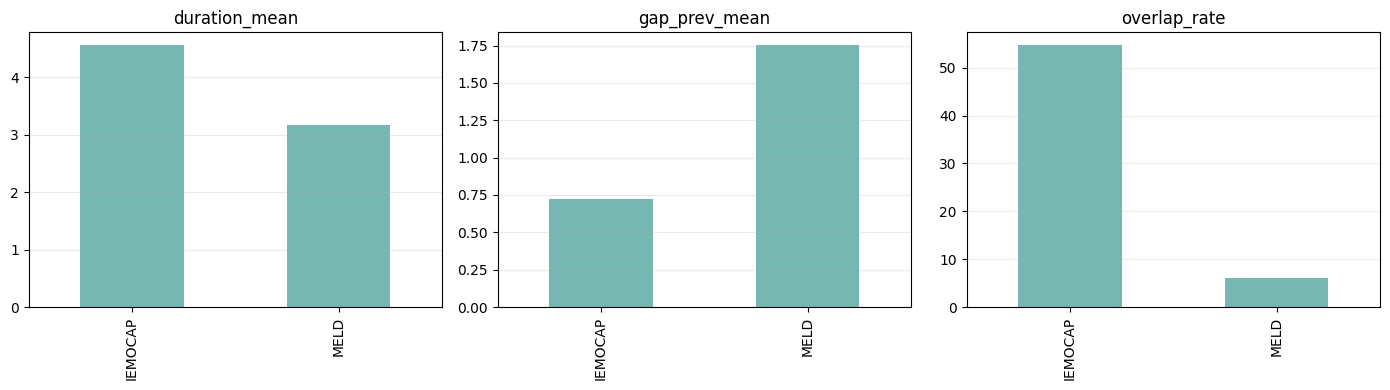

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['duration_mean', 'gap_prev_mean', 'overlap_rate']):
    comparison.plot(x='dataset', y=col, kind='bar', legend=False, ax=ax, color='#76B7B2')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(COMPARISON_REPORT_DIR / 'iemocap_vs_meld_temporal_summary.png', dpi=160)
plt.show()


In [41]:
meld_evidence_rows = []
for feature in ['duration_mean', 'gap_prev_mean', 'overlap_rate', 'interruption_rate', 'speaker_switch_rate', 'long_gap_rate']:
    values = meld_emotion_summary.set_index('emotion')[feature].dropna()
    meld_evidence_rows.append({
        'dataset': 'MELD',
        'question': 'emotion_separability',
        'feature': feature,
        'range_across_emotions': float(values.max() - values.min()),
        'max_emotion': values.idxmax(),
        'min_emotion': values.idxmin(),
    })
for feature in ['duration_mean', 'gap_prev_mean', 'overlap_rate', 'speaker_switch_rate', 'emotion_change_rate']:
    values = meld_split_summary.set_index('split')[feature].dropna()
    meld_evidence_rows.append({
        'dataset': 'MELD',
        'question': 'split_instability',
        'feature': feature,
        'range_across_splits': float(values.max() - values.min()),
        'max_split': values.idxmax(),
        'min_split': values.idxmin(),
    })
meld_evidence = pd.DataFrame(meld_evidence_rows)
meld_evidence.to_csv(MELD_REPORT_DIR / 'meld_tim_temporal_evidence_summary.csv', index=False)
meld_evidence


,dataset,question,feature,range_across_emotions,max_emotion,min_emotion,range_across_splits,max_split,min_split
0,MELD,emotion_separability,duration_mean,0.651807,sad,neutral,NaN,NaN,NaN
1,MELD,emotion_separability,gap_prev_mean,0.843359,neutral,angry,NaN,NaN,NaN
2,MELD,emotion_separability,overlap_rate,1.022488,happy,neutral,NaN,NaN,NaN
3,MELD,emotion_separability,interruption_rate,2.046744,happy,angry,NaN,NaN,NaN
4,MELD,emotion_separability,speaker_switch_rate,10.573022,happy,sad,NaN,NaN,NaN
5,MELD,emotion_separability,long_gap_rate,6.047346,sad,angry,NaN,NaN,NaN
6,MELD,split_instability,duration_mean,NaN,NaN,NaN,0.191898,test,dev
7,MELD,split_instability,gap_prev_mean,NaN,NaN,NaN,1.434602,test,dev
8,MELD,split_instability,overlap_rate,NaN,NaN,NaN,2.491089,train,test
9,MELD,split_instability,speaker_switch_rate,NaN,NaN,NaN,2.979627,dev,test


In [42]:
print('IEMOCAP reports:', REPORT_DIR)
for path in sorted(REPORT_DIR.glob('*')):
    print('  -', path.name)
print()
print('MELD reports:', MELD_REPORT_DIR)
for path in sorted(MELD_REPORT_DIR.glob('*')):
    print('  -', path.name)
print()
print('Comparison reports:', COMPARISON_REPORT_DIR)
for path in sorted(COMPARISON_REPORT_DIR.glob('*')):
    print('  -', path.name)


IEMOCAP reports: /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/iemocap_temporal_session_analysis
  - emotion_temporal_summary.csv
  - emotion_temporal_summary.png
  - emotion_transition_counts.csv
  - emotion_transition_temporal_summary.csv
  - iemocap_temporal_features_by_utterance.csv
  - session_emotion_counts.csv
  - session_emotion_ratio.csv
  - session_emotion_ratio.png
  - session_emotion_temporal_heatmaps.png
  - session_emotion_temporal_summary.csv
  - session_temporal_summary.csv
  - session_temporal_summary.png
  - tim_temporal_evidence_summary.csv

MELD reports: /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_temporal_analysis
  - meld_emotion_temporal_summary.csv
  - meld_emotion_temporal_summary.png
  - meld_emotion_transition_temporal_summary.csv
  - meld_metadata_4class.csv
  - meld_season_temporal_summary.csv
  - meld_split_temporal_summary.csv
  - meld_split_temporal_summary.png
  - meld_temporal_features_by_utt